In [ ]:
import torch
import gc
from torch import nn
import numpy as np
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,Subset,TensorDataset
from torch.nn import functional as F
import matplotlib.pyplot as plt

Funzione create_conv_detector: una funzione che restituisce una convoluzione e l'insieme dei kernel da impostare alla rete

In [ ]:
def create_conv_detector():
  kernels = [create_kernel(i) for i in range(512)]
  tensor_kernel = torch.stack(kernels).unsqueeze(1)
  net = nn.Conv2d(1,512,3,padding='valid',bias=False)
  with torch.no_grad():
    net.weight.copy_(tensor_kernel)
  return net,tensor_kernel

Funzione FeatureDetector: ho implementato un modulo che riconosce i kernel all'interno di un immagine

In [ ]:
class FeatureDetector(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv, kernels = create_conv_detector()
        # In __init__:
        ones_count = (kernels == 1.0).sum(dim=(1, 2, 3)).float().view(1, 512, 1, 1)
        zeros_count = (kernels == 0.0).sum(dim=(1, 2, 3)).float().view(1, 512, 1, 1)
        self.register_buffer('ones_in_kernel', ones_count)
        self.register_buffer('zeros_in_kernel', zeros_count)

    def forward(self, batch):
        match_ones = self.conv(batch)
        match_zeros = F.conv2d(1.0 - batch, 1.0 - self.conv.weight, padding=self.conv.padding)
        detection = ((match_ones == self.ones_in_kernel) & (match_zeros == self.zeros_in_kernel)).float()
        return detection

Funzione create_kernel: funzione che ti permette di creare una matrice 3x3 in base al numero decimale inserito (da 0 a 511)

In [ ]:
def create_kernel(num):
  binary_num = bin(num)[2:].zfill(9)
  np_array = np.array([float(bit) for bit in binary_num], dtype=np.float32)
  kernel = torch.from_numpy(np_array.reshape(3, 3))
  return kernel
kernels = [create_kernel(i) for i in range(512)]
tensor_kernel = torch.stack(kernels).unsqueeze(1)

Funzione CountBitPattern: funzione che conta il numero di feature trovate dal Feature Detector

In [ ]:
def CountBitPattern(featureDet,image):
  with torch.no_grad():
      detection = featureDet(image)
  counts = detection.sum(dim=(-2, -1))
  return counts.long()

Implementazione MNIST: qui vado a istanziare il dataset MNIST, trasformato in un tensore e fatto osservare un campione di 100 immagini del dataset

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 452kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.68MB/s]


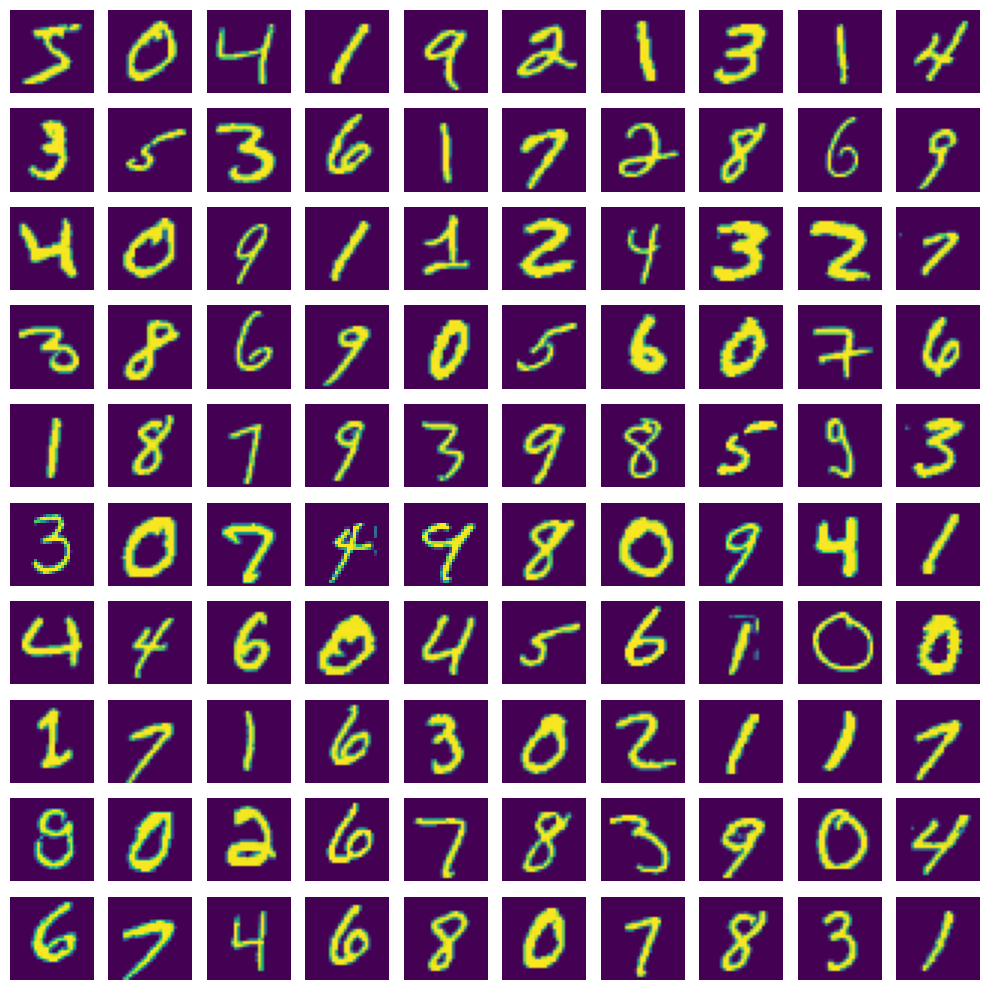

In [ ]:
train_data=datasets.MNIST(root='./data',train=True,download=True,transform=transforms.ToTensor())
test_data=datasets.MNIST(root='./data',train=False,download=True,transform=transforms.ToTensor())
images=np.array([image for image in train_data.data])
fig, axes = plt.subplots(nrows=10,ncols=10, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
  ax.imshow(images[i])
  ax.axis('off')
plt.tight_layout()
plt.show()

Binarizzazione MNIST: implemento il dataset MNIST ma ogni valore viene binarizzato (cioè viene impostato a 0 o 1 i valori dei pixel in base ad una soglia). Anche qui ho fatto vedere un campione di 100 immagini e risulta che non ci sia una differenza notevole rispetto a prima

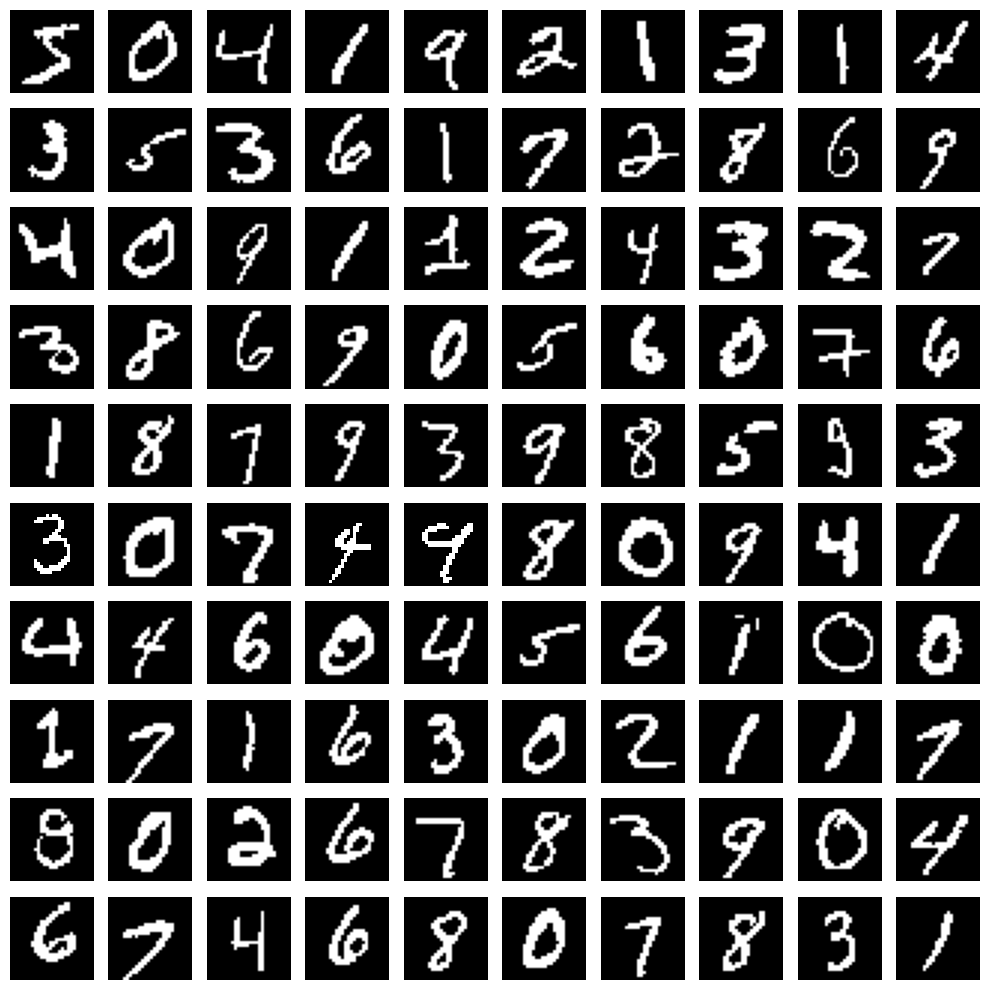

In [ ]:
binary_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x>0.5).float()),
])
train_data_binarized=datasets.MNIST(root='./data',train=True,download=True,transform=binary_transform)
test_data_binarized=datasets.MNIST(root='./data',train=False,download=True,transform=binary_transform)
images_bin=np.array([image for image in train_data_binarized.data])
fig, axes = plt.subplots(nrows=10,ncols=10, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
  img, label = train_data_binarized[i]
  img2d=img.squeeze(0)
  ax.imshow(img2d,cmap='gray',vmin=0,vmax=1)
  ax.axis('off')
plt.tight_layout()
plt.show()

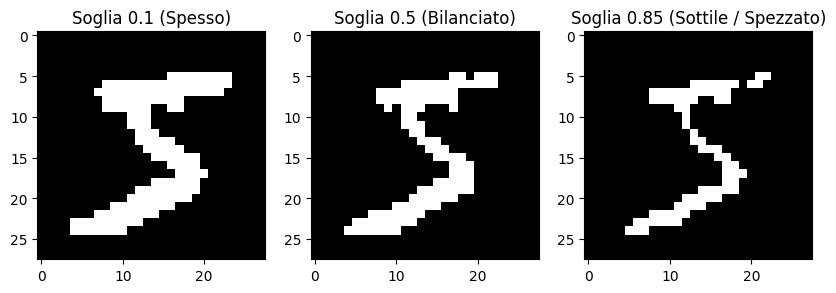

In [ ]:
img,label=train_data[0]
img=img.squeeze()
soglia_bassa = (img > 0.1).float()
soglia_media = (img > 0.5).float()
soglia_alta  = (img > 0.85).float()
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(soglia_bassa.squeeze(), cmap='gray')
axes[0].set_title("Soglia 0.1 (Spesso)")
axes[1].imshow(soglia_media.squeeze(), cmap='gray')
axes[1].set_title("Soglia 0.5 (Bilanciato)")
axes[2].imshow(soglia_alta.squeeze(), cmap='gray')
axes[2].set_title("Soglia 0.85 (Sottile / Spezzato)")
plt.show()

Conteggio dei pattens: qui si usa la funzione CountBitPattern per contare le occorrenze dei vari kernel nel dataset. Per motivi di complessità e per impedimenti dell'hardware il conteggio viene fatto su un Subset di 3000 immagini

In [ ]:
batch_size=2000
all_counts = []
#num_subset=3000
#train_subset = Subset(train_data_binarized, range(num_subset))
full_train_loader = DataLoader(train_data_binarized, batch_size=batch_size, shuffle=False)
featureDet = FeatureDetector()
for batch_idx, (images, labels) in enumerate(full_train_loader):
    batch_counts = CountBitPattern(featureDet,images)
    all_counts.append(batch_counts)
dataset_bit_pattern_counts = torch.cat(all_counts, dim=0)

Qui si utilizza la funzione di Maximum Entropy per ricavare i pattern salienti. Per ricavare i pattern salienti ho calcolato la frequenza delle occorrenze delle varie feature (p_i), poi ho calcolato la funzione che rappresenta la salienza di ciascun pattern, dopodichè questi valori li ho ordinati in ordine decrescente e ricavato i primi K=32 (la scelta di K è arbitraria)

In [ ]:
total_counts=dataset_bit_pattern_counts.sum(dim=0)
N_total=total_counts.sum()
p_i=total_counts/N_total
eps = 1e-12
information_p=-torch.log(p_i+eps)
numeratore=p_i*information_p
N=512
W=0.05
denominatore=torch.maximum(torch.tensor(1.0/N,device=p_i.device),p_i/W)
f_p=numeratore/denominatore
sorted_info=torch.sort(f_p,descending=True)
K = 32
top_values, top_indices = torch.topk(f_p, k=K, largest=True)
print("Indici dei pattern più salienti:", top_indices.tolist())
print("Punteggi f_p corrispondenti:", top_values.tolist())
kernels_salient=tensor_kernel[top_indices]

Indici dei pattern più salienti: [306, 329, 402, 313, 147, 312, 303, 208, 120, 304, 51, 88, 60, 210, 22, 150, 52, 489, 59, 191, 403, 506, 263, 240, 155, 434, 449, 5, 47, 30, 90, 23]
Punteggi f_p corrispondenti: [0.4597099721431732, 0.4596978425979614, 0.4582987427711487, 0.4580399692058563, 0.4556753933429718, 0.4544200897216797, 0.4519296884536743, 0.45010504126548767, 0.4498056173324585, 0.44858723878860474, 0.44775235652923584, 0.4464854598045349, 0.44619765877723694, 0.44494518637657166, 0.4431277811527252, 0.44154253602027893, 0.4410891532897949, 0.43878594040870667, 0.4370908737182617, 0.43690603971481323, 0.4353081285953522, 0.4349535405635834, 0.434724897146225, 0.4337988793849945, 0.4334031045436859, 0.4334031045436859, 0.4317187964916229, 0.43034493923187256, 0.4296884834766388, 0.4294760227203369, 0.4271394610404968, 0.4269185960292816]


Classe VeroFeatureDetector: questa classe a differenza del Feature Detector prende in ingresso i kernel più salienti e crea una convoluzione che modificherà il dataset MNIST

In [ ]:
class VeroFeatureDetector(nn.Module):
    def __init__(self, salient_kernels):
        super(VeroFeatureDetector, self).__init__()
        # 1. Ricava K (numero di feature salienti, es. 32 o 64)
        self.K = salient_kernels.shape[0]
        # 2. Strato convoluzionale senza bias (operazione puramente deterministica)
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=self.K,
            kernel_size=3,
            padding='valid',
            bias=False
        )
        # 3. Assegnazione e congelamento dei K pesi salienti
        with torch.no_grad():
            self.conv.weight.copy_(salient_kernels)
        self.conv.weight.requires_grad = False
        ones_count = (salient_kernels == 1.0).sum(dim=(1, 2, 3)).float().view(1, self.K, 1, 1)
        zeros_count = (salient_kernels == 0.0).sum(dim=(1, 2, 3)).float().view(1, self.K, 1, 1)
        self.register_buffer('ones_in_kernel', ones_count)
        self.register_buffer('zeros_in_kernel', zeros_count)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 3. Secondo livello Convoluzionale Addestrabile
        # Prende in input i K canali del detector e ne sputa 64 (o quanti ne vuoi)
        self.conv2 = nn.Conv2d(
            in_channels=self.K,
            out_channels=64,
            kernel_size=3,
            padding='same' # 'same' mantiene la dimensione spaziale
        )

    def forward(self, batch):
      x_bin=(batch>0.5).float()
      match_ones = self.conv(x_bin)
      inverted_kernel=1-self.conv.weight
      match_zeros = F.conv2d(1.0 - x_bin, inverted_kernel, padding=self.conv.padding)
      detection = ((match_ones == self.ones_in_kernel) & (match_zeros == self.zeros_in_kernel)).float()
      x = self.pool(detection)       # Riduce le dimensioni spaziali (es. 26x26 -> 13x13)
      x = F.relu(self.conv2(x))
      return x

Classe SimpleCNN: una rete neurale convolutiva per il dataset MNIST originale e binarizzato.

In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self, kernels, in_channels=1 ,num_classes=10, input_spatial_size=28):
    super(SimpleCNN,self).__init__()
    self.conv1=nn.Conv2d(in_channels=in_channels,out_channels=512,kernel_size=3,padding='valid')
    with torch.no_grad():
        self.conv1.weight.copy_(kernels)
    self.conv1.weight.requires_grad = False
    self.flatten=nn.Flatten()
    self.fc=nn.Linear(512 * 26 * 26, num_classes)

  def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

Classe SimpleCNNAfterFeatureExtraction: una rete neurale convolutiva che a differenza di prima i canali in input sono K (il numero dei kernel più salienti)

In [ ]:
class SimpleCNNAfterFeatureExtraction(nn.Module):
  def __init__(self, K ,num_classes=10):
    super(SimpleCNNAfterFeatureExtraction,self).__init__()
    self.feature_detector=VeroFeatureDetector(kernels_salient)
    self.flatten = nn.Flatten()
    self.fc = nn.Linear(28*28,num_classes)

  def forward(self, x):
        x = F.relu(x)
        x = self.flatten(x)
        x=self.fc(x)
        return x

funzione training_fun: funzione di addestramento delle CNN, dove calcolo per ogni addestramento la training loss, la validation loss e l'accuratezza

In [ ]:
def training_fun(model, train_loader, test_loader, epochs=5, lr=0.001):
  criterion=nn.CrossEntropyLoss()
  optimizer=torch.optim.Adam(model.parameters(),lr=lr)
  device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)
  training_loss_history=[] #Qui memorizzo il training loss lungo le epoche
  validation_loss_history=[] #Qui memorizzo il validation loss lungo le epoche
  for epoch in range(epochs):
    model.train()
    running_training_loss=0.0
    for images,labels in train_loader:
      images,labels=images.to(device),labels.to(device)
      optimizer.zero_grad() #azzeramento dei gradienti
      output=model(images)
      loss=criterion(output,labels)
      running_training_loss+=loss.item()*images.size(0) #training loss data dalla loss per la dimensione del batch
      loss.backward() #calcolo gradiente dell'errore rispetto al peso
      optimizer.step() #Aggiorna i pesi
    epoch_training_loss=running_training_loss/len(train_loader.dataset) #calcolo loss media dell'intera epoca
    training_loss_history.append(epoch_training_loss)
    model.eval()
    running_validation_loss=0.0
    correct=0
    total=0
    with torch.no_grad():
      for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        outputs=model(images)
        loss=criterion(outputs,labels)
        running_validation_loss+=loss.item()*images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_validation_loss=running_validation_loss/len(test_loader.dataset)
    validation_loss_history.append(epoch_validation_loss)
  accuracy = 100 * correct / total
  return accuracy,training_loss_history,validation_loss_history

funzione comparation_cnn: funzione in cui viene mostrato in grafico i parametri calcolati nella training_fun

In [ ]:
def comparation_cnn(model,label,train_loader,test_loader,epochs=5,lr=0.001):
  accuracy_original,training_loss_original,validation_loss_original=training_fun(model,train_loader,test_loader,epochs=epochs,lr=lr)
  plt.plot(np.arange(1,epochs+1),training_loss_original,label='Training Loss',color="blue")
  plt.plot(np.arange(1,epochs+1),validation_loss_original,label='Validation Loss',color="red")
  print(f"Accuratezza MNIST {label}: {accuracy_original}%")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.grid(True)
  plt.legend()
  plt.show()

Qui eseguo gli effettivi test: nel primo caso eseguo SimpleCNN sul dataset MNIST originale, nel secondo caso eseguo SimpleCNN sul dataaset MNIST binarizzato e nel terzo caso uso la CNN dopo la feature extraction

In [ ]:
train_loader_original=DataLoader(train_data,batch_size=batch_size,shuffle=False)
test_loader_original=DataLoader(test_data,batch_size=batch_size,shuffle=False)

Accuratezza MNIST originale: 91.78%


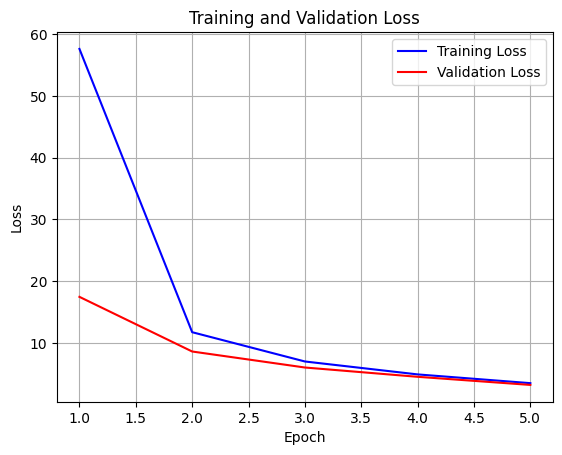

In [ ]:
batch_size=32
model1=SimpleCNN(kernels=tensor_kernel)
comparation_cnn(model1,'originale',train_loader_original,test_loader_original,epochs=5,lr=0.001)

Accuratezza MNIST binarizzata: 92.94%


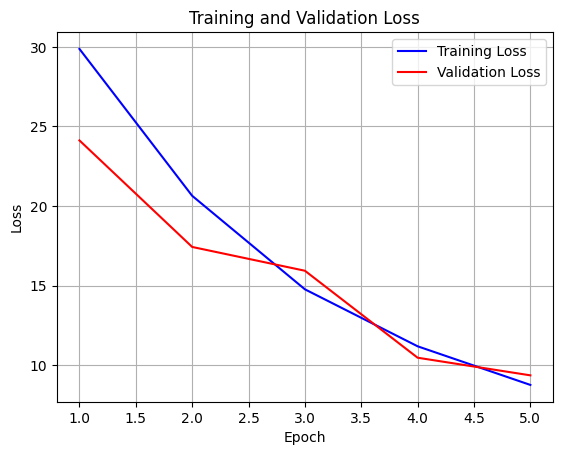

In [ ]:
train_loader_binarized=DataLoader(train_data_binarized,batch_size=batch_size,shuffle=True)
test_loader_binarized=DataLoader(test_data_binarized,batch_size=batch_size,shuffle=False)
model2=SimpleCNN(kernels=tensor_kernel)
comparation_cnn(model2,'binarizzata',train_loader_binarized,test_loader_binarized,epochs=5,lr=0.001)

Accuratezza MNIST dopo feature extraction: 91.95%


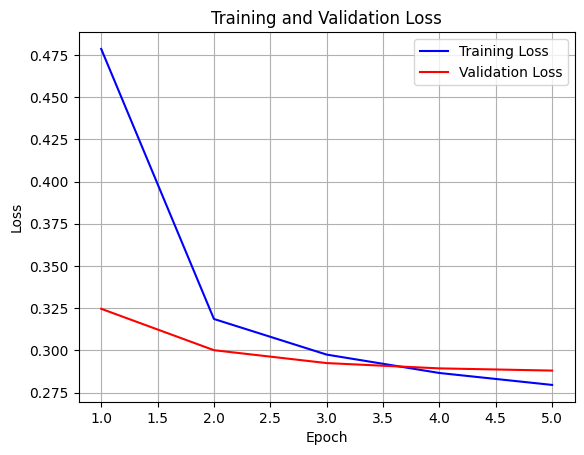

In [ ]:
model_feat=SimpleCNNAfterFeatureExtraction(K)
comparation_cnn(model_feat,'dopo feature extraction',train_loader_binarized,test_loader_binarized,epochs=5,lr=0.001)